Cell 1

In [1]:
!nvidia-smi

Thu Mar 26 16:43:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA RTX PRO 6000 Blac...    Off |   00000000:05:00.0 Off |                    0 |
| N/A   28C    P0             45W /  600W |       0MiB /  97887MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

Cell 2

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os

BASE = "/content/drive/MyDrive/trellis_project"
for folder in ["hf_cache", "outputs", "data", "models", "logs", "notebooks", "results"]:
    os.makedirs(f"{BASE}/{folder}", exist_ok=True)

print("BASE =", BASE)

Mounted at /content/drive
BASE = /content/drive/MyDrive/trellis_project


Cell 3

In [3]:
%%bash
set -e

if [ ! -d /usr/local/miniforge ]; then
  wget -qO /tmp/Miniforge3.sh "https://github.com/conda-forge/miniforge/releases/latest/download/Miniforge3-Linux-x86_64.sh"
  bash /tmp/Miniforge3.sh -b -p /usr/local/miniforge
else
  echo "Miniforge already installed"
fi

PREFIX=/usr/local/miniforge
Unpacking bootstrapper...
Unpacking payload...
Extracting ca-certificates-2026.2.25-hbd8a1cb_0.conda
Extracting libgomp-15.2.0-he0feb66_18.conda
Extracting libzlib-1.3.2-h25fd6f3_2.conda
Extracting nlohmann_json-abi-3.12.0-h0f90c79_1.conda
Extracting pybind11-abi-11-hc364b38_1.conda
Extracting python_abi-3.13-8_cp313.conda
Extracting tzdata-2025c-hc9c84f9_1.conda
Extracting _openmp_mutex-4.5-20_gnu.conda
Extracting zstd-1.5.7-hb78ec9c_6.conda
Extracting ld_impl_linux-64-2.45.1-default_hbd61a6d_101.conda
Extracting libgcc-15.2.0-he0feb66_18.conda
Extracting bzip2-1.0.8-hda65f42_9.conda
Extracting c-ares-1.34.6-hb03c661_0.conda
Extracting keyutils-1.6.3-hb9d3cd8_0.conda
Extracting libexpat-2.7.4-hecca717_0.conda
Extracting libffi-3.5.2-h3435931_0.conda
Extracting libgcc-ng-15.2.0-h69a702a_18.conda
Extracting libiconv-1.18-h3b78370_2.conda
Extracting liblzma-5.8.2-hb03c661_0.conda
Extracting libmpdec-4.0.0-hb03c661_1.conda
Extracting libstdcxx-15.2.0-h934c35e_1

Cell 4

In [4]:
import os
os.environ["PATH"] = "/usr/local/miniforge/bin:" + os.environ["PATH"]

!conda --version
!mamba --version

conda 26.1.1
2.5.0


Cell 5

In [5]:
%%bash
set -e
cd /content

if [ ! -d /content/TRELLIS ]; then
  git clone --recurse-submodules https://github.com/microsoft/TRELLIS.git
else
  echo "TRELLIS already present"
fi

cd /content/TRELLIS
git rev-parse HEAD

Submodule path 'trellis/representations/mesh/flexicubes': checked out '815e075a2a400d06c48d94c347674344ed6ae5c5'
442aa1e1afb9014e80681d3bf604e8d728a86ee7


Cloning into 'TRELLIS'...
Submodule 'trellis/representations/mesh/flexicubes' (https://github.com/MaxtirError/FlexiCubes.git) registered for path 'trellis/representations/mesh/flexicubes'
Cloning into '/content/TRELLIS/trellis/representations/mesh/flexicubes'...


Cell 6

In [6]:
%%bash
set -e

unset PYTHONPATH || true
source /usr/local/miniforge/etc/profile.d/conda.sh

for i in 1 2 3; do
  if conda env list | awk '{print $1}' | grep -qx "trellis"; then
    echo "conda env 'trellis' already exists"
    break
  fi

  echo "Attempt $i: creating conda env..."
  mamba create -y -n trellis -c conda-forge python=3.10 && break

  echo "Env creation failed on attempt $i"
  sleep 10
done

conda activate trellis
python --version
which python

Attempt 1: creating conda env...


Transaction

  Prefix: /usr/local/miniforge/envs/trellis

  Updating specs:

   - python=3.10


  Package               Version  Build                 Channel           Size
───────────────────────────────────────────────────────────────────────────────
  Install:
───────────────────────────────────────────────────────────────────────────────

  + _openmp_mutex           4.5  20_gnu                conda-forge     Cached
  + bzip2                 1.0.8  hda65f42_9            conda-forge     Cached
  + ca-certificates   2026.2.25  hbd8a1cb_0            conda-forge     Cached
  + icu                    78.3  h33c6efd_0            conda-forge     Cached
  + ld_impl_linux-64     2.45.1  default_hbd61a6d_102  conda-forge      728kB
  + libexpat              2.7.4  hecca717_0            conda-forge     Cached
  + libffi                3.5.2  h3435931_0            conda-forge     Cached
  + libgcc               15.2.0  he0feb66_18           conda-forge     Ca

Cell 7

In [7]:
import os

BASE = "/content/drive/MyDrive/trellis_project"

os.environ["PATH"] = "/usr/local/miniforge/bin:" + os.environ["PATH"]
os.environ["HF_HOME"] = f"{BASE}/hf_cache"
os.environ["TORCH_HOME"] = f"{BASE}/hf_cache"
os.environ["SPCONV_ALGO"] = "native"
os.environ.pop("ATTN_BACKEND", None)  # leave unset for now

for k in ["HF_HOME", "TORCH_HOME", "SPCONV_ALGO", "ATTN_BACKEND"]:
    print(k, "=", os.environ.get(k))

HF_HOME = /content/drive/MyDrive/trellis_project/hf_cache
TORCH_HOME = /content/drive/MyDrive/trellis_project/hf_cache
SPCONV_ALGO = native
ATTN_BACKEND = None


Cell 8

In [8]:
%%bash
set -e

unset PYTHONPATH || true
source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis

python -m pip install --upgrade pip

pip uninstall -y torch torchvision torchaudio kaolin xformers || true

pip install --no-cache-dir \
  torch==2.8.0 torchvision==0.23.0 torchaudio==2.8.0 \
  --index-url https://download.pytorch.org/whl/cu128

pip install --no-cache-dir \
  kaolin==0.18.0 \
  -f https://nvidia-kaolin.s3.us-east-2.amazonaws.com/torch-2.8.0_cu128.html

Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 168.7 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 183.0 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 172.7 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 706.8/706.8 MB 225.2 MB/s  0:00:03
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 594.3/594.3 MB 173.1 MB/s  0:00:03
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 164.6 MB/s  0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 164.7 MB/s  0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 267.5/267.5 MB 146.1 MB/s  0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 288.2/288.2 MB 166.9 MB/s  0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.2/287.2 MB 140.2 MB/s  0:00:02
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.4/322.4 MB 169.2 MB/s  0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.3/39.3 

Cell 9

In [9]:
%%bash
set -e

unset PYTHONPATH || true
source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis

pip install --no-cache-dir easydict

Cell 10

In [10]:
%%bash
set -e

unset PYTHONPATH || true
source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis

pip install --no-cache-dir rembg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 189.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.7/3.7 MB 157.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 100.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.8/14.8 MB 40.0 MB/s  0:00:00



Cell 11

In [11]:
%%bash
set -e

unset PYTHONPATH || true
source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis

pip install --no-cache-dir onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.4/17.4 MB 174.4 MB/s  0:00:00



Cell 12

In [12]:
%%bash
set -e

unset PYTHONPATH || true
source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis

pip install --no-cache-dir transformers sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 161.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 625.2/625.2 kB 717.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 313.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 137.4 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 479.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 kB 589.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 791.7/791.7 kB 583.4 MB/s  0:00:00



Cell 13

In [13]:
%%bash
set -e

unset PYTHONPATH || true
source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis

export HF_HOME=/content/drive/MyDrive/trellis_project/hf_cache
export TORCH_HOME=/content/drive/MyDrive/trellis_project/hf_cache
export SPCONV_ALGO=native
unset ATTN_BACKEND || true

python - <<'PY'
import importlib, subprocess, sys

# keep the already-needed basics
needed = [
    ("open3d", "open3d"),
    ("plyfile", "plyfile"),
]

missing = []
for pip_name, mod_name in needed:
    try:
        importlib.import_module(mod_name)
    except Exception:
        missing.append(pip_name)

print("missing basic deps:", missing)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-cache-dir", *missing])

# make sure we do NOT keep the unrelated tiny PyPI utils3d package
subprocess.run([sys.executable, "-m", "pip", "uninstall", "-y", "utils3d"], check=False)

# install the utils3d package TRELLIS expects
subprocess.check_call([
    sys.executable, "-m", "pip", "install", "--no-cache-dir",
    "git+https://github.com/EasternJournalist/utils3d.git"
])
PY

cd /content/TRELLIS

python - <<'PY'
import torch
import kaolin
import open3d as o3d
import plyfile
import utils3d

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))
    x = torch.randn(1024, 1024, device="cuda")
    y = x @ x
    print("matmul ok:", y.shape)

print("kaolin: OK")
print("open3d: OK", o3d.__version__)
print("plyfile: OK", getattr(plyfile, "__version__", "imported"))
print("utils3d: OK", utils3d.__file__)
print("utils3d has torch:", hasattr(utils3d, "torch"))

from trellis.pipelines import TrellisImageTo3DPipeline
print("TRELLIS import OK")
PY

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 447.7/447.7 MB 224.1 MB/s  0:00:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 200.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 232.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 267.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 478.7 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 246.1 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 252.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 231.9 MB/s  0:00:00

  Cloning https://github.com/EasternJournalist/utils3d.git to /tmp/pip-req-build-uuc0872k
  Resolved https://github.com/EasternJournalist/utils3d.git to commit 6abd5afc22c326eb8ee93945d5980dde2dcf3b3b
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: fini

  Running command git clone --filter=blob:none --quiet https://github.com/EasternJournalist/utils3d.git /tmp/pip-req-build-uuc0872k


Cell 14

In [14]:
%%bash
set -e

unset PYTHONPATH || true
source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis
cd /content/TRELLIS

python - <<'PY'
import os, json, subprocess, torch, platform

BASE = "/content/drive/MyDrive/trellis_project"
commit = subprocess.check_output(["git", "rev-parse", "HEAD"], text=True).strip()

meta = {
    "trellis_commit": commit,
    "python": platform.python_version(),
    "torch": torch.__version__,
    "cuda_version": torch.version.cuda,
    "cuda_available": torch.cuda.is_available(),
    "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else None,
    "HF_HOME": os.environ.get("HF_HOME"),
    "TORCH_HOME": os.environ.get("TORCH_HOME"),
    "ATTN_BACKEND": os.environ.get("ATTN_BACKEND"),
    "SPCONV_ALGO": os.environ.get("SPCONV_ALGO"),
}

os.makedirs(f"{BASE}/results", exist_ok=True)
with open(f"{BASE}/results/run_metadata.json", "w") as f:
    json.dump(meta, f, indent=2)

print(json.dumps(meta, indent=2))
PY

{
  "trellis_commit": "442aa1e1afb9014e80681d3bf604e8d728a86ee7",
  "python": "3.10.20",
  "torch": "2.8.0+cu128",
  "cuda_version": "12.8",
  "cuda_available": true,
  "gpu_name": "NVIDIA RTX PRO 6000 Blackwell Server Edition",
  "HF_HOME": "/content/drive/MyDrive/trellis_project/hf_cache",
  "TORCH_HOME": "/content/drive/MyDrive/trellis_project/hf_cache",
  "ATTN_BACKEND": null,
  "SPCONV_ALGO": "native"
}


Cell 14.5

In [15]:
from pathlib import Path
import os

BASE = Path("/content/drive/MyDrive/trellis_project")
REPO = Path("/content/TRELLIS")
OUT = REPO / "workflow_out_ip2p_t1"
DRIVE_OUT = BASE / "outputs" / "trellis1_ip2p_workflow"

OUT.mkdir(parents=True, exist_ok=True)
DRIVE_OUT.mkdir(parents=True, exist_ok=True)

os.environ["PATH"] = "/usr/local/miniforge/bin:" + os.environ["PATH"]
os.environ["HF_HOME"] = str(BASE / "hf_cache")
os.environ["TORCH_HOME"] = str(BASE / "hf_cache")
os.environ["SPCONV_ALGO"] = "native"

print("REPO      =", REPO)
print("OUT       =", OUT)
print("DRIVE_OUT =", DRIVE_OUT)
print("HF_HOME   =", os.environ["HF_HOME"])

REPO      = /content/TRELLIS
OUT       = /content/TRELLIS/workflow_out_ip2p_t1
DRIVE_OUT = /content/drive/MyDrive/trellis_project/outputs/trellis1_ip2p_workflow
HF_HOME   = /content/drive/MyDrive/trellis_project/hf_cache


Cell 15

In [16]:
%%bash
set -euo pipefail

unset PYTHONPATH || true
source /usr/local/miniforge/etc/profile.d/conda.sh
conda activate trellis

python - <<'PY'
import importlib, subprocess, sys

mods = [
    ("diffusers", "diffusers"),
    ("accelerate", "accelerate"),
    ("safetensors", "safetensors"),
    ("trimesh", "trimesh"),
    ("scipy", "scipy"),
]
missing = []
for pip_name, mod_name in mods:
    try:
        importlib.import_module(mod_name)
    except Exception:
        missing.append(pip_name)

print("missing:", missing)
if missing:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "--no-cache-dir", *missing])

import diffusers, accelerate, trimesh, scipy
print("diffusers:", diffusers.__version__)
print("accelerate:", accelerate.__version__)
print("trimesh:", trimesh.__version__)
print("scipy:", scipy.__version__)
PY

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 99.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.8/740.8 kB 330.3 MB/s  0:00:00

missing: ['diffusers', 'accelerate', 'trimesh']
diffusers: 0.37.1
accelerate: 1.13.0
trimesh: 4.11.5
scipy: 1.15.3


Cell 16

In [41]:
from pathlib import Path

work_dir = Path("/content/TRELLIS/workflow_out_ip2p_t1")
work_dir.mkdir(parents=True, exist_ok=True)

# =========================
# MASTER WORKFLOW SETTINGS
# =========================

# SOURCE_MODE:
#   "upload"  -> ask for your own image
#   "dataset" -> use Pix2Pix dataset/library
SOURCE_MODE = "dataset"

# Single-item preview controls
DATASET_START_IDX = 1
DATASET_N_SHOW = 12
DATASET_CHOSEN_LOCAL_IDX = 0

# If SOURCE_MODE == "dataset":
# choose whether the selected dataset image starts from original or already-edited
DATASET_IMAGE_KIND = "edited"
# "original" or "edited"

# If SOURCE_MODE == "upload":
# choose whether to reuse an already-uploaded file if present
REUSE_EXISTING_UPLOAD = True

# =========================
# EDIT SETTINGS
# =========================

# True  -> run Pix2Pix edit before TRELLIS
# False -> send selected image directly to TRELLIS
RUN_IP2P_EDIT = False

# PROMPT_MODE used only when RUN_IP2P_EDIT=True
#   "dataset" -> use dataset edit prompt
#   "generic" -> use generic cleanup prompt
#   "custom"  -> use your own prompt
PROMPT_MODE = "dataset"

CUSTOM_EDIT_PROMPT = "make this look like a clean single centered object on a plain background"
GENERIC_EDIT_PROMPT = "make this the same single object as a clean studio product photo, centered, plain background"
NEGATIVE_PROMPT = "extra objects, hands, people, text, clutter, reflections, busy background, cut off object"

IP2P_STEPS = 20
TEXT_GUIDANCE = 7.5
IMAGE_GUIDANCE = 1.5
IP2P_SEED = 123

# =========================
# TRELLIS SETTINGS
# =========================

T1_MODEL_ID = "microsoft/TRELLIS-image-large"
T1_SS_STEPS = 18
T1_SLAT_STEPS = 18
T1_SS_CFG = 7.5
T1_SLAT_CFG = 3.0

# =========================
# DATASET BUILDER SETTINGS
# =========================

BUILD_DATASET_SAMPLE = True
DATASET_ROOT = "/content/drive/MyDrive/trellis_project/datasets/trellis1_ip2p_teacher_pairs"
DATASET_SAMPLE_ID = ""
APPEND_DATASET_INDEX = True

SAVE_STL = True
SAVE_OBJ = True
SAVE_GLB = True
SAVE_PLY = True

# =========================
# DATASET SWEEP SETTINGS
# =========================

# True  -> real sweep execution in Cell 20.1
# False -> normal single-sample workflow only
RUN_DATASET_SWEEP = True

# Inclusive global dataset id range
DATASET_SWEEP_START_ID = 101
DATASET_SWEEP_END_ID = 1000

# How to use each selected dataset item:
#   "original_only"      -> dataset original image only
#   "edited_only"        -> dataset edited image only
#   "original_and_edit"  -> dataset original image as input, then run Pix2Pix edit
#   "edited_direct"      -> dataset edited image goes directly to TRELLIS
DATASET_SWEEP_MODE = "edited_direct"

# Prompt choice during sweep when an edit is run:
#   "dataset" / "generic" / "custom"
DATASET_SWEEP_PROMPT_MODE = "dataset"

# Optional cap after applying the id range
DATASET_SWEEP_MAX_ITEMS = None

print("SOURCE_MODE                =", SOURCE_MODE)
print("DATASET_START_IDX          =", DATASET_START_IDX)
print("DATASET_N_SHOW             =", DATASET_N_SHOW)
print("DATASET_CHOSEN_LOCAL_IDX   =", DATASET_CHOSEN_LOCAL_IDX)
print("DATASET_IMAGE_KIND         =", DATASET_IMAGE_KIND)
print("REUSE_EXISTING_UPLOAD      =", REUSE_EXISTING_UPLOAD)

print("RUN_IP2P_EDIT              =", RUN_IP2P_EDIT)
print("PROMPT_MODE                =", PROMPT_MODE)
print("IP2P_STEPS                 =", IP2P_STEPS)
print("TEXT_GUIDANCE              =", TEXT_GUIDANCE)
print("IMAGE_GUIDANCE             =", IMAGE_GUIDANCE)
print("IP2P_SEED                  =", IP2P_SEED)

print("T1_MODEL_ID                =", T1_MODEL_ID)
print("T1_SS_STEPS                =", T1_SS_STEPS)
print("T1_SLAT_STEPS              =", T1_SLAT_STEPS)
print("T1_SS_CFG                  =", T1_SS_CFG)
print("T1_SLAT_CFG                =", T1_SLAT_CFG)

print("BUILD_DATASET_SAMPLE       =", BUILD_DATASET_SAMPLE)
print("DATASET_ROOT               =", DATASET_ROOT)
print("DATASET_SAMPLE_ID          =", DATASET_SAMPLE_ID if str(DATASET_SAMPLE_ID).strip() else "<auto>")
print("APPEND_DATASET_INDEX       =", APPEND_DATASET_INDEX)
print("SAVE_STL                   =", SAVE_STL)
print("SAVE_OBJ                   =", SAVE_OBJ)
print("SAVE_GLB                   =", SAVE_GLB)
print("SAVE_PLY                   =", SAVE_PLY)

print("RUN_DATASET_SWEEP          =", RUN_DATASET_SWEEP)
print("DATASET_SWEEP_START_ID     =", DATASET_SWEEP_START_ID)
print("DATASET_SWEEP_END_ID       =", DATASET_SWEEP_END_ID)
print("DATASET_SWEEP_MODE         =", DATASET_SWEEP_MODE)
print("DATASET_SWEEP_PROMPT_MODE  =", DATASET_SWEEP_PROMPT_MODE)
print("DATASET_SWEEP_MAX_ITEMS    =", DATASET_SWEEP_MAX_ITEMS)

SOURCE_MODE                = dataset
DATASET_START_IDX          = 1
DATASET_N_SHOW             = 12
DATASET_CHOSEN_LOCAL_IDX   = 0
DATASET_IMAGE_KIND         = edited
REUSE_EXISTING_UPLOAD      = True
RUN_IP2P_EDIT              = False
PROMPT_MODE                = dataset
IP2P_STEPS                 = 20
TEXT_GUIDANCE              = 7.5
IMAGE_GUIDANCE             = 1.5
IP2P_SEED                  = 123
T1_MODEL_ID                = microsoft/TRELLIS-image-large
T1_SS_STEPS                = 18
T1_SLAT_STEPS              = 18
T1_SS_CFG                  = 7.5
T1_SLAT_CFG                = 3.0
BUILD_DATASET_SAMPLE       = True
DATASET_ROOT               = /content/drive/MyDrive/trellis_project/datasets/trellis1_ip2p_teacher_pairs
DATASET_SAMPLE_ID          = <auto>
APPEND_DATASET_INDEX       = True
SAVE_STL                   = True
SAVE_OBJ                   = True
SAVE_GLB                   = True
SAVE_PLY                   = True
RUN_DATASET_SWEEP          = True
DATASET_SWEEP_START_ID     =

Cell 16.1

In [42]:
from pathlib import Path
import shutil
import json
import io
from PIL import Image

work_dir = Path("/content/TRELLIS/workflow_out_ip2p_t1")
work_dir.mkdir(parents=True, exist_ok=True)

upload_path = work_dir / "source_object.png"
dataset_original_path = work_dir / "dataset_source.png"
dataset_edited_path = work_dir / "dataset_edited.png"

dataset_original_prompt_path = work_dir / "dataset_original_prompt.txt"
dataset_edit_prompt_path = work_dir / "dataset_edit_prompt.txt"
dataset_edited_prompt_path = work_dir / "dataset_edited_prompt.txt"

source_choice_meta = work_dir / "source_choice.json"

if SOURCE_MODE == "upload":
    if upload_path.exists() and REUSE_EXISTING_UPLOAD:
        print("Reusing existing upload:", upload_path)
        img = Image.open(upload_path).convert("RGBA")
    else:
        from google.colab import files
        uploaded = files.upload()
        if len(uploaded) == 0:
            raise RuntimeError("No file uploaded.")
        first_name = next(iter(uploaded))
        img = Image.open(io.BytesIO(uploaded[first_name])).convert("RGBA")
        img.save(upload_path)
        print("Saved uploaded image to:", upload_path)

    meta = {
        "source_mode": "upload",
        "upload_path": str(upload_path),
    }
    source_choice_meta.write_text(json.dumps(meta, indent=2))

    display(img)

elif SOURCE_MODE == "dataset":
    from datasets import load_dataset
    from itertools import islice
    import matplotlib.pyplot as plt

    ds = load_dataset(
        "timbrooks/instructpix2pix-clip-filtered",
        split="train",
        streaming=True,
    )

    samples = list(islice(ds, DATASET_START_IDX, DATASET_START_IDX + DATASET_N_SHOW))

    if len(samples) == 0:
        raise RuntimeError("No dataset samples loaded for the requested preview window.")

    ncols = 4
    nrows = (len(samples) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for i, ax in enumerate(axes):
        if i < len(samples):
            row = samples[i]
            ax.imshow(row["edited_image"])
            ax.set_title(
                f"local_idx={i} | global_idx={DATASET_START_IDX + i}\nedit: {row['edit_prompt'][:55]}",
                fontsize=9
            )
            ax.axis("off")
        else:
            ax.axis("off")

    plt.tight_layout()
    plt.show()

    chosen_idx = DATASET_CHOSEN_LOCAL_IDX
    if not (0 <= chosen_idx < len(samples)):
        raise ValueError(f"DATASET_CHOSEN_LOCAL_IDX must be between 0 and {len(samples)-1}")

    row = samples[chosen_idx]

    src_img = row["original_image"].convert("RGBA")
    edit_img = row["edited_image"].convert("RGBA")

    src_img.save(dataset_original_path)
    edit_img.save(dataset_edited_path)

    dataset_original_prompt_path.write_text(row["original_prompt"], encoding="utf-8")
    dataset_edit_prompt_path.write_text(row["edit_prompt"], encoding="utf-8")
    dataset_edited_prompt_path.write_text(row["edited_prompt"], encoding="utf-8")

    meta = {
        "source_mode": "dataset",
        "dataset_start_idx": DATASET_START_IDX,
        "dataset_n_show": DATASET_N_SHOW,
        "dataset_chosen_local_idx": chosen_idx,
        "dataset_chosen_global_idx": DATASET_START_IDX + chosen_idx,
        "dataset_image_kind": DATASET_IMAGE_KIND,
        "dataset_original_path": str(dataset_original_path),
        "dataset_edited_path": str(dataset_edited_path),
        "original_prompt": row["original_prompt"],
        "edit_prompt": row["edit_prompt"],
        "edited_prompt": row["edited_prompt"],
    }
    source_choice_meta.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")

    print("Chosen dataset local_idx :", chosen_idx)
    print("Chosen dataset global_idx:", DATASET_START_IDX + chosen_idx)
    print("original_prompt          :", row["original_prompt"])
    print("edit_prompt              :", row["edit_prompt"])
    print("edited_prompt            :", row["edited_prompt"])

    display(src_img)
    display(edit_img)

else:
    raise ValueError(f"Bad SOURCE_MODE: {SOURCE_MODE}")

Output hidden; open in https://colab.research.google.com to view.

Cell 17

In [43]:
from pathlib import Path
import json

work_dir = Path("/content/TRELLIS/workflow_out_ip2p_t1")

upload_path = work_dir / "source_object.png"
dataset_original_path = work_dir / "dataset_source.png"
dataset_edited_path = work_dir / "dataset_edited.png"

dataset_original_prompt_path = work_dir / "dataset_original_prompt.txt"
dataset_edit_prompt_path = work_dir / "dataset_edit_prompt.txt"
dataset_edited_prompt_path = work_dir / "dataset_edited_prompt.txt"

if SOURCE_MODE == "upload":
    SELECTED_SOURCE_PATH = upload_path
    SELECTED_SOURCE_KIND = "upload"
    ORIGINAL_TEXT = None
    DATASET_EDIT_PROMPT = None
    EDITED_TEXT = None

elif SOURCE_MODE == "dataset":
    if DATASET_IMAGE_KIND == "original":
        SELECTED_SOURCE_PATH = dataset_original_path
        SELECTED_SOURCE_KIND = "dataset_original"
    elif DATASET_IMAGE_KIND == "edited":
        SELECTED_SOURCE_PATH = dataset_edited_path
        SELECTED_SOURCE_KIND = "dataset_edited"
    else:
        raise ValueError(f"Bad DATASET_IMAGE_KIND: {DATASET_IMAGE_KIND}")

    ORIGINAL_TEXT = dataset_original_prompt_path.read_text(encoding="utf-8").strip() if dataset_original_prompt_path.exists() else None
    DATASET_EDIT_PROMPT = dataset_edit_prompt_path.read_text(encoding="utf-8").strip() if dataset_edit_prompt_path.exists() else None
    EDITED_TEXT = dataset_edited_prompt_path.read_text(encoding="utf-8").strip() if dataset_edited_prompt_path.exists() else None

else:
    raise ValueError(f"Bad SOURCE_MODE: {SOURCE_MODE}")

if not SELECTED_SOURCE_PATH.exists():
    raise FileNotFoundError(f"Missing selected source: {SELECTED_SOURCE_PATH}")

if RUN_IP2P_EDIT:
    if PROMPT_MODE == "dataset":
        if DATASET_EDIT_PROMPT is None:
            raise RuntimeError("PROMPT_MODE='dataset' but no dataset edit prompt exists.")
        RESOLVED_EDIT_PROMPT = DATASET_EDIT_PROMPT
    elif PROMPT_MODE == "generic":
        RESOLVED_EDIT_PROMPT = GENERIC_EDIT_PROMPT
    elif PROMPT_MODE == "custom":
        RESOLVED_EDIT_PROMPT = CUSTOM_EDIT_PROMPT
    else:
        raise ValueError(f"Bad PROMPT_MODE: {PROMPT_MODE}")
else:
    RESOLVED_EDIT_PROMPT = None

resolved_meta = {
    "selected_source_path": str(SELECTED_SOURCE_PATH),
    "selected_source_kind": SELECTED_SOURCE_KIND,
    "original_text": ORIGINAL_TEXT,
    "dataset_edit_prompt": DATASET_EDIT_PROMPT,
    "edited_text": EDITED_TEXT,
    "run_ip2p_edit": bool(RUN_IP2P_EDIT),
    "resolved_edit_prompt": RESOLVED_EDIT_PROMPT,
}
(work_dir / "resolved_choice.json").write_text(json.dumps(resolved_meta, indent=2, ensure_ascii=False), encoding="utf-8")

print("SELECTED_SOURCE_PATH  =", SELECTED_SOURCE_PATH)
print("SELECTED_SOURCE_KIND  =", SELECTED_SOURCE_KIND)
print("RUN_IP2P_EDIT         =", RUN_IP2P_EDIT)
print("RESOLVED_EDIT_PROMPT  =", RESOLVED_EDIT_PROMPT)
print("ORIGINAL_TEXT         =", ORIGINAL_TEXT)
print("EDITED_TEXT           =", EDITED_TEXT)
print("T1_MODEL_ID           =", T1_MODEL_ID)

SELECTED_SOURCE_PATH  = /content/TRELLIS/workflow_out_ip2p_t1/dataset_edited.png
SELECTED_SOURCE_KIND  = dataset_edited
RUN_IP2P_EDIT         = False
RESOLVED_EDIT_PROMPT  = None
ORIGINAL_TEXT         = Picture winter, animals, snow, stream, fire, the moon, spruce, the fire, tent, axe, painting, deer, Darrell …
EDITED_TEXT           = Picture cartoon, animals, snow, stream, fire, the moon, spruce, the fire, tent, axe, painting, deer, Darrell …
T1_MODEL_ID           = microsoft/TRELLIS-image-large


Cell 18

No edit requested.
WROTE /content/TRELLIS/workflow_out_ip2p_t1/final_input_rgb.png
WROTE /content/TRELLIS/workflow_out_ip2p_t1/final_input_rgba.png
WROTE /content/TRELLIS/workflow_out_ip2p_t1/final_input_preview.png


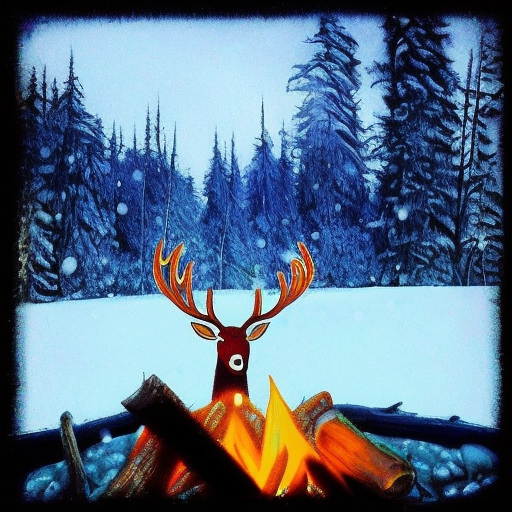

In [44]:
import os
import subprocess
import textwrap
import json
from pathlib import Path
from PIL import Image

work_dir = Path("/content/TRELLIS/workflow_out_ip2p_t1")
work_dir.mkdir(parents=True, exist_ok=True)

selected_source_path = Path(SELECTED_SOURCE_PATH)

final_rgb_path = work_dir / "final_input_rgb.png"
final_rgba_path = work_dir / "final_input_rgba.png"
final_preview_path = work_dir / "final_input_preview.png"
workflow_json_path = work_dir / "workflow_choice.json"

if not RUN_IP2P_EDIT:
    src_rgb = Image.open(selected_source_path).convert("RGB")
    src_rgba = Image.open(selected_source_path).convert("RGBA")

    src_rgb.save(final_rgb_path)
    src_rgba.save(final_rgba_path)
    src_rgb.save(final_preview_path)

    meta = {
        "selected_source_path": str(selected_source_path),
        "run_ip2p_edit": False,
        "resolved_edit_prompt": None,
        "final_rgb_path": str(final_rgb_path),
        "final_rgba_path": str(final_rgba_path),
    }
    workflow_json_path.write_text(json.dumps(meta, indent=2))

    print("No edit requested.")
    print("WROTE", final_rgb_path)
    print("WROTE", final_rgba_path)
    print("WROTE", final_preview_path)
    display(src_rgb)

else:
    repo_root = "/content/TRELLIS"
    env_python = "/usr/local/miniforge/envs/trellis/bin/python"
    script_path = Path("/content/TRELLIS/run_ip2p_edit_for_trellis1.py")

    script_path.write_text(textwrap.dedent(f"""
import io
import json
import torch
from pathlib import Path
from PIL import Image

from diffusers import StableDiffusionInstructPix2PixPipeline, EulerAncestralDiscreteScheduler
from rembg import remove

work_dir = Path("/content/TRELLIS/workflow_out_ip2p_t1")
source_path = Path({str(selected_source_path)!r})

edited_rgb_path = work_dir / "pix2pix_edited_rgb.png"
edited_rgba_path = work_dir / "pix2pix_edited_rgba.png"
preview_path = work_dir / "pix2pix_preview.png"

final_rgb_path = work_dir / "final_input_rgb.png"
final_rgba_path = work_dir / "final_input_rgba.png"
final_preview_path = work_dir / "final_input_preview.png"
workflow_json_path = work_dir / "workflow_choice.json"

prompt = {RESOLVED_EDIT_PROMPT!r}
negative_prompt = {NEGATIVE_PROMPT!r}
steps = {IP2P_STEPS}
guidance = {TEXT_GUIDANCE}
image_guidance = {IMAGE_GUIDANCE}
seed = {IP2P_SEED}

if not source_path.exists():
    raise FileNotFoundError(source_path)

source = Image.open(source_path).convert("RGB")

pipe = StableDiffusionInstructPix2PixPipeline.from_pretrained(
    "timbrooks/instruct-pix2pix",
    torch_dtype=torch.float16,
    safety_checker=None,
)
pipe.scheduler = EulerAncestralDiscreteScheduler.from_config(pipe.scheduler.config)
pipe.to("cuda")

generator = torch.Generator(device="cuda").manual_seed(seed)
edited = pipe(
    prompt,
    negative_prompt=negative_prompt,
    image=source,
    num_inference_steps=steps,
    guidance_scale=guidance,
    image_guidance_scale=image_guidance,
    generator=generator,
).images[0].convert("RGB")
edited.save(edited_rgb_path)

buf = io.BytesIO()
edited.save(buf, format="PNG")
rgba_bytes = remove(buf.getvalue())
edited_rgba = Image.open(io.BytesIO(rgba_bytes)).convert("RGBA")
edited_rgba.save(edited_rgba_path)

edited.save(final_rgb_path)
edited_rgba.save(final_rgba_path)

preview = Image.new("RGB", (source.width + edited.width, max(source.height, edited.height)), (255, 255, 255))
preview.paste(source, (0, 0))
preview.paste(edited, (source.width, 0))
preview.save(preview_path)
preview.save(final_preview_path)

meta = {{
    "selected_source_path": str(source_path),
    "run_ip2p_edit": True,
    "resolved_edit_prompt": prompt,
    "negative_prompt": negative_prompt,
    "pix2pix_edited_rgb_path": str(edited_rgb_path),
    "pix2pix_edited_rgba_path": str(edited_rgba_path),
    "final_rgb_path": str(final_rgb_path),
    "final_rgba_path": str(final_rgba_path),
}}
workflow_json_path.write_text(json.dumps(meta, indent=2))

print("WROTE", edited_rgb_path)
print("WROTE", edited_rgba_path)
print("WROTE", final_rgb_path)
print("WROTE", final_rgba_path)
print("WROTE", preview_path)
"""))

    env = os.environ.copy()
    env["HF_HOME"] = "/content/drive/MyDrive/trellis_project/hf_cache"
    env["TORCH_HOME"] = "/content/drive/MyDrive/trellis_project/hf_cache"

    result = subprocess.run(
        [env_python, str(script_path)],
        env=env,
        text=True,
        capture_output=True,
    )

    print("=== Cell 18 STDOUT ===")
    print(result.stdout)
    print("=== Cell 18 STDERR ===")
    print(result.stderr)
    print("=== Cell 18 EXIT CODE ===", result.returncode)

    if result.returncode != 0:
        raise RuntimeError("Cell 18 failed. Stop here and send only Cell 18 output.")

    display(Image.open(final_preview_path))

Cell 19

In [45]:
import os
import subprocess
import textwrap
from pathlib import Path

repo_root = Path("/content/TRELLIS")
env_python = "/usr/local/miniforge/envs/trellis/bin/python"

env = os.environ.copy()
env["HF_HOME"] = "/content/drive/MyDrive/trellis_project/hf_cache"
env["TORCH_HOME"] = "/content/drive/MyDrive/trellis_project/hf_cache"
env["PYTHONPATH"] = f"{repo_root}:{env.get('PYTHONPATH', '')}"
env["PATH"] = "/usr/local/cuda/bin:/usr/bin:/bin:" + env.get("PATH", "")
env["CC"] = "/usr/bin/gcc"
env["CXX"] = "/usr/bin/g++"
env["CUDA_HOME"] = "/usr/local/cuda"
env["LD_LIBRARY_PATH"] = "/usr/local/cuda/lib64:" + env.get("LD_LIBRARY_PATH", "")
env["SPCONV_ALGO"] = "native"
env["ATTN_BACKEND"] = "sdpa"                 # dense attention
env["SPARSE_ATTN_BACKEND"] = "flash_attn"   # sparse path uses local stub
env["MAX_JOBS"] = "2"
env["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"

# --- ensure spconv exists inside the trellis env ---
check_spconv = subprocess.run(
    [env_python, "-c", "import spconv.pytorch as spconv; print(spconv.__file__)"],
    env=env,
    text=True,
    capture_output=True,
)

if check_spconv.returncode != 0:
    print("spconv missing in trellis env; installing spconv-cu120 ...")
    install_spconv = subprocess.run(
        [env_python, "-m", "pip", "install", "-q", "spconv-cu120"],
        env=env,
        text=True,
        capture_output=True,
    )
    print("=== SPCONV INSTALL STDOUT ===")
    print(install_spconv.stdout)
    print("=== SPCONV INSTALL STDERR ===")
    print(install_spconv.stderr)
    print("=== SPCONV INSTALL EXIT CODE ===", install_spconv.returncode)

    if install_spconv.returncode != 0:
        raise RuntimeError("Cell 19 failed while installing spconv-cu120. Paste only this cell's output.")

    check_spconv = subprocess.run(
        [env_python, "-c", "import spconv.pytorch as spconv; print(spconv.__file__)"],
        env=env,
        text=True,
        capture_output=True,
    )

print("=== SPCONV CHECK STDOUT ===")
print(check_spconv.stdout)
print("=== SPCONV CHECK STDERR ===")
print(check_spconv.stderr)
print("=== SPCONV CHECK EXIT CODE ===", check_spconv.returncode)

if check_spconv.returncode != 0:
    raise RuntimeError("Cell 19 failed: spconv still not importable in trellis env. Paste only this cell's output.")

script_template = r'''
import os
import sys
import json
import textwrap
from pathlib import Path

import trimesh
from PIL import Image
from huggingface_hub import snapshot_download

repo_root = Path("/content/TRELLIS")
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.chdir(repo_root)

os.environ["SPCONV_ALGO"] = "native"
os.environ["ATTN_BACKEND"] = "sdpa"
os.environ["SPARSE_ATTN_BACKEND"] = "flash_attn"

import spconv.pytorch as spconv
print("spconv import OK:", spconv.__file__)

# --- flash_attn stub backed by torch sdpa ---
flash_pkg = repo_root / "flash_attn"
flash_pkg.mkdir(exist_ok=True)
(flash_pkg / "__init__.py").write_text(textwrap.dedent("""\
import torch
import torch.nn.functional as F

__version__ = "2.7.0"

def _sdpa_one(q, k, v):
    qh = q.transpose(0, 1).unsqueeze(0)   # [1, H, Lq, C]
    kh = k.transpose(0, 1).unsqueeze(0)   # [1, H, Lk, C]
    vh = v.transpose(0, 1).unsqueeze(0)   # [1, H, Lk, C]
    out = F.scaled_dot_product_attention(qh, kh, vh, dropout_p=0.0, is_causal=False)
    return out.squeeze(0).transpose(0, 1).contiguous()  # [Lq, H, C]

def _segments(cu):
    cu = cu.detach().cpu().tolist()
    return list(zip(cu[:-1], cu[1:]))

def flash_attn_varlen_qkvpacked_func(qkv, cu_seqlens, max_seqlen, *args, **kwargs):
    outs = []
    for s, e in _segments(cu_seqlens):
        q = qkv[s:e, 0]
        k = qkv[s:e, 1]
        v = qkv[s:e, 2]
        outs.append(_sdpa_one(q, k, v))
    return torch.cat(outs, dim=0)

def flash_attn_varlen_kvpacked_func(q, kv, cu_seqlens_q, cu_seqlens_k, max_seqlen_q, max_seqlen_k, *args, **kwargs):
    outs = []
    q_segs = _segments(cu_seqlens_q)
    k_segs = _segments(cu_seqlens_k)
    for (qs, qe), (ks, ke) in zip(q_segs, k_segs):
        qq = q[qs:qe]
        kk = kv[ks:ke, 0]
        vv = kv[ks:ke, 1]
        outs.append(_sdpa_one(qq, kk, vv))
    return torch.cat(outs, dim=0)

def flash_attn_varlen_func(q, k, v, cu_seqlens_q, cu_seqlens_k, max_seqlen_q, max_seqlen_k, *args, **kwargs):
    outs = []
    q_segs = _segments(cu_seqlens_q)
    k_segs = _segments(cu_seqlens_k)
    for (qs, qe), (ks, ke) in zip(q_segs, k_segs):
        qq = q[qs:qe]
        kk = k[ks:ke]
        vv = v[ks:ke]
        outs.append(_sdpa_one(qq, kk, vv))
    return torch.cat(outs, dim=0)

def flash_attn_qkvpacked_func(qkv, *args, **kwargs):
    outs = []
    for i in range(qkv.shape[0]):
        q = qkv[i, :, 0]
        k = qkv[i, :, 1]
        v = qkv[i, :, 2]
        outs.append(_sdpa_one(q, k, v).unsqueeze(0))
    return torch.cat(outs, dim=0)

def flash_attn_kvpacked_func(q, kv, *args, **kwargs):
    outs = []
    for i in range(q.shape[0]):
        qq = q[i]
        kk = kv[i, :, 0]
        vv = kv[i, :, 1]
        outs.append(_sdpa_one(qq, kk, vv).unsqueeze(0))
    return torch.cat(outs, dim=0)

def flash_attn_func(q, k, v, *args, **kwargs):
    outs = []
    for i in range(q.shape[0]):
        outs.append(_sdpa_one(q[i], k[i], v[i]).unsqueeze(0))
    return torch.cat(outs, dim=0)
"""))
print("Created flash_attn sdpa-backed stub at", flash_pkg)

# --- utils3d compatibility shims ---
import utils3d
import utils3d.torch as u3dt

try:
    _ = u3dt.intrinsics_from_fov_xy
except Exception:
    base_fn = u3dt.intrinsics_from_fov
    def intrinsics_from_fov_xy(fov_x, fov_y):
        return base_fn(fov_x=fov_x, fov_y=fov_y)
    u3dt.intrinsics_from_fov_xy = intrinsics_from_fov_xy

try:
    _ = u3dt.perspective_from_fov_xy
except Exception:
    base_fn = u3dt.perspective_from_fov
    def perspective_from_fov_xy(fov_x, fov_y, near, far):
        return base_fn(fov_x=fov_x, fov_y=fov_y, near=near, far=far)
    u3dt.perspective_from_fov_xy = perspective_from_fov_xy

print("utils3d intrinsics_from_fov_xy ready")
print("utils3d perspective_from_fov_xy ready")
print("Skipping rasterization shim in raw-mesh export mode")

# --- image-only pipeline import ---
pipelines_init = repo_root / "trellis/pipelines/__init__.py"
pipelines_init.write_text(
    "from .base import Pipeline\n"
    "from .trellis_image_to_3d import TrellisImageTo3DPipeline\n"
)
print("Patched trellis/pipelines/__init__.py to image-only import")

# --- sparse package env-aware ---
sparse_init = repo_root / "trellis/modules/sparse/__init__.py"
sparse_init.write_text(textwrap.dedent("""\
from typing import *
import importlib
import os

BACKEND = 'spconv'
DEBUG = False
ATTN = 'flash_attn'

def __from_env():
    global BACKEND
    global DEBUG
    global ATTN

    env_sparse_backend = os.environ.get('SPARSE_BACKEND')
    env_sparse_debug = os.environ.get('SPARSE_DEBUG')
    env_sparse_attn = os.environ.get('SPARSE_ATTN_BACKEND')
    if env_sparse_attn is None:
        env_sparse_attn = os.environ.get('ATTN_BACKEND')

    if env_sparse_backend is not None and env_sparse_backend in ['spconv', 'torchsparse']:
        BACKEND = env_sparse_backend
    if env_sparse_debug is not None:
        DEBUG = env_sparse_debug == '1'
    if env_sparse_attn is not None and env_sparse_attn in ['xformers', 'flash_attn', 'sdpa']:
        ATTN = env_sparse_attn

    print(f"[SPARSE] Backend: {BACKEND}, Attention: {ATTN}")

__from_env()

def set_backend(backend: Literal['spconv', 'torchsparse']):
    global BACKEND
    BACKEND = backend

def set_debug(debug: bool):
    global DEBUG
    DEBUG = debug

def set_attn(attn: Literal['xformers', 'flash_attn', 'sdpa']):
    global ATTN
    ATTN = attn

__attributes = {
    'SparseTensor': 'basic',
    'sparse_batch_broadcast': 'basic',
    'sparse_batch_op': 'basic',
    'sparse_cat': 'basic',
    'sparse_unbind': 'basic',
    'SparseGroupNorm': 'norm',
    'SparseLayerNorm': 'norm',
    'SparseGroupNorm32': 'norm',
    'SparseLayerNorm32': 'norm',
    'SparseReLU': 'nonlinearity',
    'SparseSiLU': 'nonlinearity',
    'SparseGELU': 'nonlinearity',
    'SparseActivation': 'nonlinearity',
    'SparseLinear': 'linear',
    'sparse_scaled_dot_product_attention': 'attention',
    'SerializeMode': 'attention',
    'sparse_serialized_scaled_dot_product_self_attention': 'attention',
    'sparse_windowed_scaled_dot_product_self_attention': 'attention',
    'SparseMultiHeadAttention': 'attention',
    'SparseConv3d': 'conv',
    'SparseInverseConv3d': 'conv',
    'SparseDownsample': 'spatial',
    'SparseUpsample': 'spatial',
    'SparseSubdivide': 'spatial',
}

__submodules = ['transformer']
__all__ = list(__attributes.keys()) + __submodules

def __getattr__(name):
    if name not in globals():
        if name in __attributes:
            module_name = __attributes[name]
            module = importlib.import_module(f".{module_name}", __name__)
            globals()[name] = getattr(module, name)
        elif name in __submodules:
            module = importlib.import_module(f".{name}", __name__)
            globals()[name] = module
        else:
            raise AttributeError(f"module {__name__} has no attribute {name}")
    return globals()[name]
"""))
print("Overwrote trellis/modules/sparse/__init__.py")

# --- full attention ---
full_attn_py = repo_root / "trellis/modules/sparse/attention/full_attn.py"
full_attn_py.write_text(textwrap.dedent("""\
from typing import *
import torch
from .. import SparseTensor
from .. import DEBUG, ATTN

if ATTN == 'xformers':
    import xformers.ops as xops
elif ATTN == 'flash_attn':
    import flash_attn
else:
    raise ValueError(f"Unknown attention module: {ATTN}")

__all__ = [
    'sparse_scaled_dot_product_attention',
]

@overload
def sparse_scaled_dot_product_attention(qkv: SparseTensor) -> SparseTensor:
    ...
@overload
def sparse_scaled_dot_product_attention(q: SparseTensor, kv: Union[SparseTensor, torch.Tensor]) -> SparseTensor:
    ...
@overload
def sparse_scaled_dot_product_attention(q: torch.Tensor, kv: SparseTensor) -> torch.Tensor:
    ...
@overload
def sparse_scaled_dot_product_attention(q: SparseTensor, k: SparseTensor, v: SparseTensor) -> SparseTensor:
    ...
@overload
def sparse_scaled_dot_product_attention(q: SparseTensor, k: torch.Tensor, v: torch.Tensor) -> SparseTensor:
    ...
@overload
def sparse_scaled_dot_product_attention(q: torch.Tensor, k: SparseTensor, v: SparseTensor) -> torch.Tensor:
    ...

def sparse_scaled_dot_product_attention(*args, **kwargs):
    arg_names_dict = {
        1: ['qkv'],
        2: ['q', 'kv'],
        3: ['q', 'k', 'v']
    }
    num_all_args = len(args) + len(kwargs)
    assert num_all_args in arg_names_dict, f"Invalid number of arguments, got {num_all_args}, expected 1, 2, or 3"
    for key in arg_names_dict[num_all_args][len(args):]:
        assert key in kwargs, f"Missing argument {key}"

    if num_all_args == 1:
        qkv = args[0] if len(args) > 0 else kwargs['qkv']
        assert isinstance(qkv, SparseTensor), f"qkv must be a SparseTensor, got {type(qkv)}"
        assert len(qkv.shape) == 4 and qkv.shape[1] == 3, f"Invalid shape for qkv, got {qkv.shape}, expected [N, *, 3, H, C]"
        device = qkv.device
        s = qkv
        q_seqlen = [qkv.layout[i].stop - qkv.layout[i].start for i in range(qkv.shape[0])]
        kv_seqlen = q_seqlen
        qkv = qkv.feats

    elif num_all_args == 2:
        q = args[0] if len(args) > 0 else kwargs['q']
        kv = args[1] if len(args) > 1 else kwargs['kv']
        assert (isinstance(q, SparseTensor) and isinstance(kv, (SparseTensor, torch.Tensor))) or \
               (isinstance(q, torch.Tensor) and isinstance(kv, SparseTensor)), \
               f"Invalid types, got {type(q)} and {type(kv)}"
        assert q.shape[0] == kv.shape[0], f"Batch size mismatch, got {q.shape[0]} and {kv.shape[0]}"
        device = q.device

        if isinstance(q, SparseTensor):
            assert len(q.shape) == 3, f"Invalid shape for q, got {q.shape}, expected [N, *, H, C]"
            s = q
            q_seqlen = [q.layout[i].stop - q.layout[i].start for i in range(q.shape[0])]
            q = q.feats
        else:
            assert len(q.shape) == 4, f"Invalid shape for q, got {q.shape}, expected [N, L, H, C]"
            s = None
            N, L, H, C = q.shape
            q_seqlen = [L] * N
            q = q.reshape(N * L, H, C)

        if isinstance(kv, SparseTensor):
            assert len(kv.shape) == 4 and kv.shape[1] == 2, f"Invalid shape for kv, got {kv.shape}, expected [N, *, 2, H, C]"
            kv_seqlen = [kv.layout[i].stop - kv.layout[i].start for i in range(kv.shape[0])]
            kv = kv.feats
        else:
            assert len(kv.shape) == 5, f"Invalid shape for kv, got {kv.shape}, expected [N, L, 2, H, C]"
            N, L, _, H, C = kv.shape
            kv_seqlen = [L] * N
            kv = kv.reshape(N * L, 2, H, C)

    elif num_all_args == 3:
        q = args[0] if len(args) > 0 else kwargs['q']
        k = args[1] if len(args) > 1 else kwargs['k']
        v = args[2] if len(args) > 2 else kwargs['v']
        assert (isinstance(q, SparseTensor) and isinstance(k, (SparseTensor, torch.Tensor)) and type(k) == type(v)) or \
               (isinstance(q, torch.Tensor) and isinstance(k, SparseTensor) and isinstance(v, SparseTensor)), \
               f"Invalid types, got {type(q)}, {type(k)}, and {type(v)}"
        assert q.shape[0] == k.shape[0] == v.shape[0], f"Batch size mismatch, got {q.shape[0]}, {k.shape[0]}, and {v.shape[0]}"
        device = q.device

        if isinstance(q, SparseTensor):
            assert len(q.shape) == 3, f"Invalid shape for q, got {q.shape}, expected [N, *, H, Ci]"
            s = q
            q_seqlen = [q.layout[i].stop - q.layout[i].start for i in range(q.shape[0])]
            q = q.feats
        else:
            assert len(q.shape) == 4, f"Invalid shape for q, got {q.shape}, expected [N, L, H, Ci]"
            s = None
            N, L, H, CI = q.shape
            q_seqlen = [L] * N
            q = q.reshape(N * L, H, CI)

        if isinstance(k, SparseTensor):
            assert len(k.shape) == 3, f"Invalid shape for k, got {k.shape}, expected [N, *, H, Ci]"
            assert len(v.shape) == 3, f"Invalid shape for v, got {v.shape}, expected [N, *, H, Co]"
            kv_seqlen = [k.layout[i].stop - k.layout[i].start for i in range(k.shape[0])]
            k = k.feats
            v = v.feats
        else:
            assert len(k.shape) == 4, f"Invalid shape for k, got {k.shape}, expected [N, L, H, Ci]"
            assert len(v.shape) == 4, f"Invalid shape for v, got {v.shape}, expected [N, L, H, Co]"
            N, L, H, CI, CO = *k.shape, v.shape[-1]
            kv_seqlen = [L] * N
            k = k.reshape(N * L, H, CI)
            v = v.reshape(N * L, H, CO)

    if DEBUG:
        if s is not None:
            for i in range(s.shape[0]):
                assert (s.coords[s.layout[i]] == i).all(), "SparseScaledDotProductSelfAttention: batch index mismatch"

    if ATTN == 'xformers':
        if num_all_args == 1:
            q, k, v = qkv.unbind(dim=1)
        elif num_all_args == 2:
            k, v = kv.unbind(dim=1)
        q = q.unsqueeze(0)
        k = k.unsqueeze(0)
        v = v.unsqueeze(0)
        mask = xops.fmha.BlockDiagonalMask.from_seqlens(q_seqlen, kv_seqlen)
        out = xops.memory_efficient_attention(q, k, v, mask)[0]

    elif ATTN == 'flash_attn':
        cu_seqlens_q = torch.cat([torch.tensor([0]), torch.cumsum(torch.tensor(q_seqlen), dim=0)]).int().to(device)
        if num_all_args in [2, 3]:
            cu_seqlens_kv = torch.cat([torch.tensor([0]), torch.cumsum(torch.tensor(kv_seqlen), dim=0)]).int().to(device)
        if num_all_args == 1:
            out = flash_attn.flash_attn_varlen_qkvpacked_func(qkv, cu_seqlens_q, max(q_seqlen))
        elif num_all_args == 2:
            out = flash_attn.flash_attn_varlen_kvpacked_func(q, kv, cu_seqlens_q, cu_seqlens_kv, max(q_seqlen), max(kv_seqlen))
        elif num_all_args == 3:
            out = flash_attn.flash_attn_varlen_func(q, k, v, cu_seqlens_q, cu_seqlens_kv, max(q_seqlen), max(kv_seqlen))

    else:
        raise ValueError(f"Unknown attention module: {ATTN}")

    if s is not None:
        return s.replace(out)
    else:
        return out.reshape(N, L, H, -1)
"""))
print("Overwrote trellis/modules/sparse/attention/full_attn.py")

# --- serialized attention ---
serialized_attn_py = repo_root / "trellis/modules/sparse/attention/serialized_attn.py"
serialized_attn_py.write_text(textwrap.dedent("""\
from typing import *
from enum import Enum
import torch
import math
from .. import SparseTensor
from .. import DEBUG, ATTN

if ATTN == 'xformers':
    import xformers.ops as xops
elif ATTN == 'flash_attn':
    import flash_attn
else:
    raise ValueError(f"Unknown attention module: {ATTN}")

__all__ = [
    'sparse_serialized_scaled_dot_product_self_attention',
]

class SerializeMode(Enum):
    Z_ORDER = 0
    Z_ORDER_TRANSPOSED = 1
    HILBERT = 2
    HILBERT_TRANSPOSED = 3

SerializeModes = [
    SerializeMode.Z_ORDER,
    SerializeMode.Z_ORDER_TRANSPOSED,
    SerializeMode.HILBERT,
    SerializeMode.HILBERT_TRANSPOSED
]

def calc_serialization(
    tensor: SparseTensor,
    window_size: int,
    serialize_mode: SerializeMode = SerializeMode.Z_ORDER,
    shift_sequence: int = 0,
    shift_window: Tuple[int, int, int] = (0, 0, 0)
) -> Tuple[torch.Tensor, torch.Tensor, List[int], List[int]]:
    fwd_indices = []
    bwd_indices = []
    seq_lens = []
    seq_batch_indices = []
    offsets = [0]

    if 'vox2seq' not in globals():
        import vox2seq

    serialize_coords = tensor.coords[:, 1:].clone()
    serialize_coords += torch.tensor(shift_window, dtype=torch.int32, device=tensor.device).reshape(1, 3)
    if serialize_mode == SerializeMode.Z_ORDER:
        code = vox2seq.encode(serialize_coords, mode='z_order', permute=[0, 1, 2])
    elif serialize_mode == SerializeMode.Z_ORDER_TRANSPOSED:
        code = vox2seq.encode(serialize_coords, mode='z_order', permute=[1, 0, 2])
    elif serialize_mode == SerializeMode.HILBERT:
        code = vox2seq.encode(serialize_coords, mode='hilbert', permute=[0, 1, 2])
    elif serialize_mode == SerializeMode.HILBERT_TRANSPOSED:
        code = vox2seq.encode(serialize_coords, mode='hilbert', permute=[1, 0, 2])
    else:
        raise ValueError(f"Unknown serialize mode: {serialize_mode}")

    for bi, s in enumerate(tensor.layout):
        num_points = s.stop - s.start
        num_windows = (num_points + window_size - 1) // window_size
        valid_window_size = num_points / num_windows

        to_ordered = torch.argsort(code[s.start:s.stop])

        if num_windows == 1:
            fwd_indices.append(to_ordered)
            bwd_indices.append(torch.zeros_like(to_ordered).scatter_(0, to_ordered, torch.arange(num_points, device=tensor.device)))
            fwd_indices[-1] += s.start
            bwd_indices[-1] += offsets[-1]
            seq_lens.append(num_points)
            seq_batch_indices.append(bi)
            offsets.append(offsets[-1] + seq_lens[-1])
        else:
            offset = 0
            mids = [(i + 0.5) * valid_window_size + shift_sequence for i in range(num_windows)]
            split = [math.floor(i * valid_window_size + shift_sequence) for i in range(num_windows + 1)]
            bwd_index = torch.zeros((num_points,), dtype=torch.int64, device=tensor.device)
            for i in range(num_windows):
                mid = mids[i]
                valid_start = split[i]
                valid_end = split[i + 1]
                padded_start = math.floor(mid - 0.5 * window_size)
                padded_end = padded_start + window_size
                fwd_indices.append(to_ordered[torch.arange(padded_start, padded_end, device=tensor.device) % num_points])
                offset += valid_start - padded_start
                bwd_index.scatter_(0, fwd_indices[-1][valid_start-padded_start:valid_end-padded_start], torch.arange(offset, offset + valid_end - valid_start, device=tensor.device))
                offset += padded_end - valid_start
                fwd_indices[-1] += s.start
            seq_lens.extend([window_size] * num_windows)
            seq_batch_indices.extend([bi] * num_windows)
            bwd_indices.append(bwd_index + offsets[-1])
            offsets.append(offsets[-1] + num_windows * window_size)

    fwd_indices = torch.cat(fwd_indices)
    bwd_indices = torch.cat(bwd_indices)
    return fwd_indices, bwd_indices, seq_lens, seq_batch_indices

def sparse_serialized_scaled_dot_product_self_attention(
    qkv: SparseTensor,
    window_size: int,
    serialize_mode: SerializeMode = SerializeMode.Z_ORDER,
    shift_sequence: int = 0,
    shift_window: Tuple[int, int, int] = (0, 0, 0)
) -> SparseTensor:
    assert len(qkv.shape) == 4 and qkv.shape[1] == 3, f"Invalid shape for qkv, got {qkv.shape}, expected [N, *, 3, H, C]"

    serialization_spatial_cache_name = f'serialization_{serialize_mode}_{window_size}_{shift_sequence}_{shift_window}'
    serialization_spatial_cache = qkv.get_spatial_cache(serialization_spatial_cache_name)
    if serialization_spatial_cache is None:
        fwd_indices, bwd_indices, seq_lens, seq_batch_indices = calc_serialization(qkv, window_size, serialize_mode, shift_sequence, shift_window)
        qkv.register_spatial_cache(serialization_spatial_cache_name, (fwd_indices, bwd_indices, seq_lens, seq_batch_indices))
    else:
        fwd_indices, bwd_indices, seq_lens, seq_batch_indices = serialization_spatial_cache

    M = fwd_indices.shape[0]
    T = qkv.feats.shape[0]
    H = qkv.feats.shape[2]
    C = qkv.feats.shape[3]
    qkv_feats = qkv.feats[fwd_indices]

    if DEBUG:
        start = 0
        qkv_coords = qkv.coords[fwd_indices]
        for i in range(len(seq_lens)):
            assert (qkv_coords[start:start+seq_lens[i], 0] == seq_batch_indices[i]).all(), f"SparseWindowedScaledDotProductSelfAttention: batch index mismatch"
            start += seq_lens[i]

    if all([seq_len == window_size for seq_len in seq_lens]):
        B = len(seq_lens)
        N = window_size
        qkv_feats = qkv_feats.reshape(B, N, 3, H, C)
        if ATTN == 'xformers':
            q, k, v = qkv_feats.unbind(dim=2)
            out = xops.memory_efficient_attention(q, k, v)
        elif ATTN == 'flash_attn':
            out = flash_attn.flash_attn_qkvpacked_func(qkv_feats)
        else:
            raise ValueError(f"Unknown attention module: {ATTN}")
        out = out.reshape(B * N, H, C)
    else:
        if ATTN == 'xformers':
            q, k, v = qkv_feats.unbind(dim=1)
            q = q.unsqueeze(0)
            k = k.unsqueeze(0)
            v = v.unsqueeze(0)
            mask = xops.fmha.BlockDiagonalMask.from_seqlens(seq_lens)
            out = xops.memory_efficient_attention(q, k, v, mask)[0]
        elif ATTN == 'flash_attn':
            cu_seqlens = torch.cat([torch.tensor([0]), torch.cumsum(torch.tensor(seq_lens), dim=0)], dim=0).to(qkv.device).int()
            out = flash_attn.flash_attn_varlen_qkvpacked_func(qkv_feats, cu_seqlens, max(seq_lens))

    out = out[bwd_indices]

    if DEBUG:
        qkv_coords = qkv_coords[bwd_indices]
        assert torch.equal(qkv_coords, qkv.coords), "SparseWindowedScaledDotProductSelfAttention: coordinate mismatch"

    return qkv.replace(out)
"""))
print("Overwrote trellis/modules/sparse/attention/serialized_attn.py")

# --- windowed attention ---
windowed_attn_py = repo_root / "trellis/modules/sparse/attention/windowed_attn.py"
windowed_attn_py.write_text(textwrap.dedent("""\
from typing import *
import torch
import math
from .. import SparseTensor
from .. import DEBUG, ATTN

if ATTN == 'xformers':
    import xformers.ops as xops
elif ATTN == 'flash_attn':
    import flash_attn
else:
    raise ValueError(f"Unknown attention module: {ATTN}")

__all__ = [
    'sparse_windowed_scaled_dot_product_self_attention',
]

def calc_window_partition(
    tensor: SparseTensor,
    window_size: Union[int, Tuple[int, ...]],
    shift_window: Union[int, Tuple[int, ...]] = 0
) -> Tuple[torch.Tensor, torch.Tensor, List[int], List[int]]:
    DIM = tensor.coords.shape[1] - 1
    shift_window = (shift_window,) * DIM if isinstance(shift_window, int) else shift_window
    window_size = (window_size,) * DIM if isinstance(window_size, int) else window_size

    shifted_coords = tensor.coords.clone().detach()
    shifted_coords[:, 1:] += torch.tensor(shift_window, device=tensor.device, dtype=torch.int32).unsqueeze(0)

    MAX_COORDS = shifted_coords[:, 1:].max(dim=0).values.tolist()
    NUM_WINDOWS = [math.ceil((mc + 1) / ws) for mc, ws in zip(MAX_COORDS, window_size)]
    OFFSET = torch.cumprod(torch.tensor([1] + NUM_WINDOWS[::-1]), dim=0).tolist()[::-1]

    shifted_coords[:, 1:] //= torch.tensor(window_size, device=tensor.device, dtype=torch.int32).unsqueeze(0)
    shifted_indices = (shifted_coords * torch.tensor(OFFSET, device=tensor.device, dtype=torch.int32).unsqueeze(0)).sum(dim=1)

    fwd_indices = torch.argsort(shifted_indices)
    bwd_indices = torch.empty_like(fwd_indices)
    bwd_indices[fwd_indices] = torch.arange(fwd_indices.shape[0], device=tensor.device)

    seq_lens = torch.bincount(shifted_indices)
    seq_batch_indices = torch.arange(seq_lens.shape[0], device=tensor.device, dtype=torch.int32) // OFFSET[0]
    mask = seq_lens != 0
    seq_lens = seq_lens[mask].tolist()
    seq_batch_indices = seq_batch_indices[mask].tolist()

    return fwd_indices, bwd_indices, seq_lens, seq_batch_indices

def sparse_windowed_scaled_dot_product_self_attention(
    qkv: SparseTensor,
    window_size: int,
    shift_window: Tuple[int, int, int] = (0, 0, 0)
) -> SparseTensor:
    assert len(qkv.shape) == 4 and qkv.shape[1] == 3, f"Invalid shape for qkv, got {qkv.shape}, expected [N, *, 3, H, C]"

    serialization_spatial_cache_name = f'window_partition_{window_size}_{shift_window}'
    serialization_spatial_cache = qkv.get_spatial_cache(serialization_spatial_cache_name)
    if serialization_spatial_cache is None:
        fwd_indices, bwd_indices, seq_lens, seq_batch_indices = calc_window_partition(qkv, window_size, shift_window)
        qkv.register_spatial_cache(serialization_spatial_cache_name, (fwd_indices, bwd_indices, seq_lens, seq_batch_indices))
    else:
        fwd_indices, bwd_indices, seq_lens, seq_batch_indices = serialization_spatial_cache

    M = fwd_indices.shape[0]
    T = qkv.feats.shape[0]
    H = qkv.feats.shape[2]
    C = qkv.feats.shape[3]
    qkv_feats = qkv.feats[fwd_indices]

    if DEBUG:
        start = 0
        qkv_coords = qkv.coords[fwd_indices]
        for i in range(len(seq_lens)):
            seq_coords = qkv_coords[start:start+seq_lens[i]]
            assert (seq_coords[:, 0] == seq_batch_indices[i]).all(), f"SparseWindowedScaledDotProductSelfAttention: batch index mismatch"
            assert (seq_coords[:, 1:].max(dim=0).values - seq_coords[:, 1:].min(dim=0).values < window_size).all(), \
                f"SparseWindowedScaledDotProductSelfAttention: window size exceeded"
            start += seq_lens[i]

    if all([seq_len == window_size for seq_len in seq_lens]):
        B = len(seq_lens)
        N = window_size
        qkv_feats = qkv_feats.reshape(B, N, 3, H, C)
        if ATTN == 'xformers':
            q, k, v = qkv_feats.unbind(dim=2)
            out = xops.memory_efficient_attention(q, k, v)
        elif ATTN == 'flash_attn':
            out = flash_attn.flash_attn_qkvpacked_func(qkv_feats)
        else:
            raise ValueError(f"Unknown attention module: {ATTN}")
        out = out.reshape(B * N, H, C)
    else:
        if ATTN == 'xformers':
            q, k, v = qkv_feats.unbind(dim=1)
            q = q.unsqueeze(0)
            k = k.unsqueeze(0)
            v = v.unsqueeze(0)
            mask = xops.fmha.BlockDiagonalMask.from_seqlens(seq_lens)
            out = xops.memory_efficient_attention(q, k, v, mask)[0]
        elif ATTN == 'flash_attn':
            cu_seqlens = torch.cat([torch.tensor([0]), torch.cumsum(torch.tensor(seq_lens), dim=0)], dim=0).to(qkv.device).int()
            out = flash_attn.flash_attn_varlen_qkvpacked_func(qkv_feats, cu_seqlens, max(seq_lens))

    out = out[bwd_indices]

    if DEBUG:
        qkv_coords = qkv_coords[bwd_indices]
        assert torch.equal(qkv_coords, qkv.coords), "SparseWindowedScaledDotProductSelfAttention: coordinate mismatch"

    return qkv.replace(out)
"""))
print("Overwrote trellis/modules/sparse/attention/windowed_attn.py")

out_dir = Path("/content/TRELLIS/workflow_out_ip2p_t1")
input_path = out_dir / "final_input_rgba.png"
model_path_file = out_dir / "model_snapshot_path.txt"

if not input_path.exists():
    raise FileNotFoundError(input_path)

from trellis.pipelines import TrellisImageTo3DPipeline

if model_path_file.exists():
    model_dir = Path(model_path_file.read_text().strip())
else:
    model_dir = Path(snapshot_download(
        repo_id=__T1_MODEL_ID__,
        cache_dir=os.environ["HF_HOME"],
    ))
    model_path_file.write_text(str(model_dir))

if not model_dir.exists():
    raise FileNotFoundError(model_dir)

print("ATTN_BACKEND =", os.environ.get("ATTN_BACKEND"))
print("SPARSE_ATTN_BACKEND =", os.environ.get("SPARSE_ATTN_BACKEND"))
print("MODEL_DIR =", model_dir)
print("INPUT_PATH =", input_path)

image = Image.open(input_path).convert("RGBA")

pipeline = TrellisImageTo3DPipeline.from_pretrained(str(model_dir))
pipeline.cuda()

outputs = pipeline.run(
    image,
    seed=__IP2P_SEED__,
    sparse_structure_sampler_params={
        "steps": __T1_SS_STEPS__,
        "cfg_strength": __T1_SS_CFG__,
    },
    slat_sampler_params={
        "steps": __T1_SLAT_STEPS__,
        "cfg_strength": __T1_SLAT_CFG__,
    },
)

ply_path = out_dir / "trellis1_gaussian.ply"
outputs["gaussian"][0].save_ply(ply_path)

mesh = outputs["mesh"][0]
verts = mesh.vertices.detach().float().cpu().numpy()
faces = mesh.faces.detach().int().cpu().numpy()

raw_mesh = trimesh.Trimesh(vertices=verts, faces=faces, process=False)
raw_mesh.remove_unreferenced_vertices()

glb_path = out_dir / "trellis1.glb"
obj_path = out_dir / "trellis1_raw_mesh.obj"
stl_path = out_dir / "trellis1_raw_mesh.stl"

raw_mesh.export(glb_path)
raw_mesh.export(obj_path)
raw_mesh.export(stl_path)

meta = {
    "input_path": str(input_path),
    "model_dir": str(model_dir),
    "model_id": __T1_MODEL_ID__,
    "seed": __IP2P_SEED__,
    "ss_steps": __T1_SS_STEPS__,
    "ss_cfg_strength": __T1_SS_CFG__,
    "slat_steps": __T1_SLAT_STEPS__,
    "slat_cfg_strength": __T1_SLAT_CFG__,
    "attn_backend": os.environ.get("ATTN_BACKEND"),
    "sparse_attn_backend": os.environ.get("SPARSE_ATTN_BACKEND"),
    "mesh_vertices": int(raw_mesh.vertices.shape[0]),
    "mesh_faces": int(raw_mesh.faces.shape[0]),
    "raw_glb_path": str(glb_path),
    "raw_obj_path": str(obj_path),
    "raw_stl_path": str(stl_path),
    "gaussian_ply_path": str(ply_path),
    "note": "Dense attention uses sdpa. Sparse full/serialized/windowed attention are served by a local sdpa-backed flash_attn stub."
}
with open(out_dir / "trellis1_meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("WROTE", glb_path)
print("WROTE", obj_path)
print("WROTE", stl_path)
print("WROTE", ply_path)
print("RAW MESH:", raw_mesh.vertices.shape[0], "vertices,", raw_mesh.faces.shape[0], "faces")
'''

script = (
    textwrap.dedent(script_template)
    .replace("__T1_MODEL_ID__", repr(T1_MODEL_ID))
    .replace("__IP2P_SEED__", repr(IP2P_SEED))
    .replace("__T1_SS_STEPS__", repr(T1_SS_STEPS))
    .replace("__T1_SS_CFG__", repr(T1_SS_CFG))
    .replace("__T1_SLAT_STEPS__", repr(T1_SLAT_STEPS))
    .replace("__T1_SLAT_CFG__", repr(T1_SLAT_CFG))
)

script_path = repo_root / "run_trellis1_from_ip2p.py"
script_path.write_text(script)

result = subprocess.run(
    [env_python, str(script_path)],
    env=env,
    text=True,
    capture_output=True,
)

print("=== STDOUT ===")
print(result.stdout)
print("=== STDERR ===")
print(result.stderr)
print("=== EXIT CODE ===", result.returncode)

if result.returncode != 0:
    raise RuntimeError("Cell 19 failed. Paste only this cell's new stdout/stderr.")

=== SPCONV CHECK STDOUT ===
/usr/local/miniforge/envs/trellis/lib/python3.10/site-packages/spconv/pytorch/__init__.py

=== SPCONV CHECK STDERR ===
/usr/local/miniforge/envs/trellis/lib/python3.10/site-packages/spconv/pytorch/functional.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is deprecated. Please use `torch.amp.custom_fwd(args..., device_type='cuda')` instead.
  _TORCH_CUSTOM_FWD = amp.custom_fwd(cast_inputs=torch.float16)
/usr/local/miniforge/envs/trellis/lib/python3.10/site-packages/spconv/pytorch/functional.py:97: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/usr/local/miniforge/envs/trellis/lib/python3.10/site-packages/spconv/pytorch/functional.py:163: FutureWarning: `torch.cuda.amp.custom_bwd(args...)` is deprecated. Please use `torch.amp.custom_bwd(args..., device_type='cuda')` instead.
  def backward(ctx, grad_output):
/usr/local/mini

Cell 20

In [46]:
from pathlib import Path
from datetime import datetime
import shutil
import json
import re
from PIL import Image

work_dir = Path("/content/TRELLIS/workflow_out_ip2p_t1")

if not BUILD_DATASET_SAMPLE:
    print("Skipping dataset sample build because BUILD_DATASET_SAMPLE=False")

else:
    dataset_root = Path(DATASET_ROOT)
    dataset_root.mkdir(parents=True, exist_ok=True)

    requested_id = str(DATASET_SAMPLE_ID).strip()
    if requested_id:
        sample_base = re.sub(r"[^A-Za-z0-9._-]+", "_", requested_id).strip("._-")
        if not sample_base:
            sample_base = "sample"
    else:
        sample_base = "sample_" + datetime.now().strftime("%Y%m%d_%H%M%S")

    sample_dir = dataset_root / sample_base
    k = 1
    while sample_dir.exists():
        sample_dir = dataset_root / f"{sample_base}_{k:02d}"
        k += 1

    sample_id = sample_dir.name
    sample_dir.mkdir(parents=True, exist_ok=True)

    selected_source_path = Path(str(SELECTED_SOURCE_PATH))

    final_rgb_path = work_dir / "final_input_rgb.png"
    final_rgba_path = work_dir / "final_input_rgba.png"

    raw_stl_path = work_dir / "trellis1_raw_mesh.stl"
    raw_obj_path = work_dir / "trellis1_raw_mesh.obj"
    glb_path = work_dir / "trellis1.glb"
    ply_path = work_dir / "trellis1_gaussian.ply"

    if not selected_source_path.exists():
        raise FileNotFoundError(f"Missing selected source image: {selected_source_path}")

    if not final_rgb_path.exists() and not final_rgba_path.exists():
        raise FileNotFoundError("Missing Cell 18 output: final_input_rgb.png or final_input_rgba.png")

    if not raw_stl_path.exists() and not raw_obj_path.exists() and not glb_path.exists():
        raise FileNotFoundError("Missing Cell 19 output: trellis1_raw_mesh.stl or trellis1_raw_mesh.obj or trellis1.glb")

    original_2d_name = "original_2d.png"
    original_text_name = "original_text.txt"
    edit_instruction_name = "edit_instruction.txt"
    edited_2d_name = "edited_2d.png"
    edited_text_name = "edited_text.txt"

    Image.open(selected_source_path).convert("RGBA").save(sample_dir / original_2d_name)

    if final_rgba_path.exists():
        Image.open(final_rgba_path).convert("RGBA").save(sample_dir / edited_2d_name)
    else:
        Image.open(final_rgb_path).convert("RGBA").save(sample_dir / edited_2d_name)

    (sample_dir / original_text_name).write_text("" if ORIGINAL_TEXT is None else str(ORIGINAL_TEXT), encoding="utf-8")
    (sample_dir / edit_instruction_name).write_text("" if RESOLVED_EDIT_PROMPT is None else str(RESOLVED_EDIT_PROMPT), encoding="utf-8")
    (sample_dir / edited_text_name).write_text("" if EDITED_TEXT is None else str(EDITED_TEXT), encoding="utf-8")

    saved_3d = {}

    if SAVE_STL and raw_stl_path.exists():
        shutil.copy2(raw_stl_path, sample_dir / "target_mesh.stl")
        saved_3d["stl"] = "target_mesh.stl"

    if SAVE_OBJ and raw_obj_path.exists():
        shutil.copy2(raw_obj_path, sample_dir / "target_mesh.obj")
        saved_3d["obj"] = "target_mesh.obj"

    if SAVE_GLB and glb_path.exists():
        shutil.copy2(glb_path, sample_dir / "target_mesh.glb")
        saved_3d["glb"] = "target_mesh.glb"

    if SAVE_PLY and ply_path.exists():
        shutil.copy2(ply_path, sample_dir / "target_gaussian.ply")
        saved_3d["ply"] = "target_gaussian.ply"

    if not saved_3d:
        raise RuntimeError("No 3D asset files were saved for this sample.")

    if SOURCE_MODE == "dataset":
        global_dataset_id = int(DATASET_START_IDX) + int(DATASET_CHOSEN_LOCAL_IDX)
    else:
        global_dataset_id = None

    record = {
        "sample_id": sample_id,
        "task": "image_text_to_image_3d_teacher_sample",
        "teacher_pipeline": "pix2pix_then_trellis1",

        "original_2d": original_2d_name,
        "original_text": original_text_name,
        "edit_instruction": edit_instruction_name,
        "edited_2d": edited_2d_name,
        "edited_text": edited_text_name,

        "target_3d": {
            "stl": saved_3d.get("stl"),
            "obj": saved_3d.get("obj"),
            "glb": saved_3d.get("glb"),
            "ply": saved_3d.get("ply"),
        },

        "preferred_mesh_format_for_training": "obj" if saved_3d.get("obj") else ("stl" if saved_3d.get("stl") else ("glb" if saved_3d.get("glb") else None)),
        "source_mode": SOURCE_MODE,
        "selected_source_kind": SELECTED_SOURCE_KIND,
        "dataset_image_kind": DATASET_IMAGE_KIND,
        "dataset_global_id": global_dataset_id,
        "dataset_window_start": DATASET_START_IDX if SOURCE_MODE == "dataset" else None,
        "dataset_local_idx": DATASET_CHOSEN_LOCAL_IDX if SOURCE_MODE == "dataset" else None,
        "run_ip2p_edit_requested": bool(RUN_IP2P_EDIT),
        "prompt_mode_requested": PROMPT_MODE if RUN_IP2P_EDIT else None,
        "negative_prompt": str(NEGATIVE_PROMPT),
        "created_at": datetime.now().isoformat(),
        "teacher_generated": True,
    }

    record_path = sample_dir / "record.json"
    record_path.write_text(json.dumps(record, indent=2, ensure_ascii=False), encoding="utf-8")

    if APPEND_DATASET_INDEX:
        index_path = dataset_root / "index.jsonl"
        with open(index_path, "a", encoding="utf-8") as f:
            f.write(json.dumps(record, ensure_ascii=False) + "\n")
        print("APPENDED", index_path)

    print("DATASET SAMPLE CREATED:", sample_dir)
    print("WROTE", record_path)
    print("original_2d      =", sample_dir / original_2d_name)
    print("original_text    =", sample_dir / original_text_name)
    print("edit_instruction =", sample_dir / edit_instruction_name)
    print("edited_2d        =", sample_dir / edited_2d_name)
    print("edited_text      =", sample_dir / edited_text_name)
    print("saved_3d         =", saved_3d)

APPENDED /content/drive/MyDrive/trellis_project/datasets/trellis1_ip2p_teacher_pairs/index.jsonl
DATASET SAMPLE CREATED: /content/drive/MyDrive/trellis_project/datasets/trellis1_ip2p_teacher_pairs/sample_20260326_175542
WROTE /content/drive/MyDrive/trellis_project/datasets/trellis1_ip2p_teacher_pairs/sample_20260326_175542/record.json
original_2d      = /content/drive/MyDrive/trellis_project/datasets/trellis1_ip2p_teacher_pairs/sample_20260326_175542/original_2d.png
original_text    = /content/drive/MyDrive/trellis_project/datasets/trellis1_ip2p_teacher_pairs/sample_20260326_175542/original_text.txt
edit_instruction = /content/drive/MyDrive/trellis_project/datasets/trellis1_ip2p_teacher_pairs/sample_20260326_175542/edit_instruction.txt
edited_2d        = /content/drive/MyDrive/trellis_project/datasets/trellis1_ip2p_teacher_pairs/sample_20260326_175542/edited_2d.png
edited_text      = /content/drive/MyDrive/trellis_project/datasets/trellis1_ip2p_teacher_pairs/sample_20260326_175542/edit

Cell 20.1

In [47]:
from pathlib import Path
from datetime import datetime
import shutil
import json
import os
import subprocess
import textwrap
from itertools import islice

from PIL import Image
from datasets import load_dataset

dataset_root = Path(DATASET_ROOT)
dataset_root.mkdir(parents=True, exist_ok=True)

if not RUN_DATASET_SWEEP:
    print("Skipping sweep because RUN_DATASET_SWEEP=False")

else:
    if SOURCE_MODE != "dataset":
        raise ValueError("For sweep execution, set SOURCE_MODE='dataset' in Cell 16.")

    start_id = int(DATASET_SWEEP_START_ID)
    end_id = int(DATASET_SWEEP_END_ID)
    if end_id < start_id:
        raise ValueError("DATASET_SWEEP_END_ID must be >= DATASET_SWEEP_START_ID")

    all_ids = list(range(start_id, end_id + 1))
    if DATASET_SWEEP_MAX_ITEMS is not None:
        all_ids = all_ids[:int(DATASET_SWEEP_MAX_ITEMS)]

    print("Loading Pix2Pix dataset stream ...")
    ds = load_dataset(
        "timbrooks/instructpix2pix-clip-filtered",
        split="train",
        streaming=True,
    )

    rows = list(islice(ds, start_id, end_id + 1))
    if len(rows) != len(all_ids):
        raise RuntimeError(f"Expected {len(all_ids)} rows, got {len(rows)}")

    repo_root = Path("/content/TRELLIS")
    env_python = "/usr/local/miniforge/envs/trellis/bin/python"

    env = os.environ.copy()
    env["HF_HOME"] = "/content/drive/MyDrive/trellis_project/hf_cache"
    env["TORCH_HOME"] = "/content/drive/MyDrive/trellis_project/hf_cache"
    env["PYTHONPATH"] = f"{repo_root}:{env.get('PYTHONPATH', '')}"
    env["PATH"] = "/usr/local/cuda/bin:/usr/bin:/bin:" + env.get("PATH", "")
    env["CC"] = "/usr/bin/gcc"
    env["CXX"] = "/usr/bin/g++"
    env["CUDA_HOME"] = "/usr/local/cuda"
    env["LD_LIBRARY_PATH"] = "/usr/local/cuda/lib64:" + env.get("LD_LIBRARY_PATH", "")
    env["SPCONV_ALGO"] = "native"
    env["ATTN_BACKEND"] = "sdpa"
    env["SPARSE_ATTN_BACKEND"] = "flash_attn"
    env["MAX_JOBS"] = "2"
    env["PIP_DISABLE_PIP_VERSION_CHECK"] = "1"

    check_spconv = subprocess.run(
        [env_python, "-c", "import spconv.pytorch as spconv; print(spconv.__file__)"],
        env=env,
        text=True,
        capture_output=True,
    )
    print("=== SPCONV CHECK STDOUT ===")
    print(check_spconv.stdout)
    print("=== SPCONV CHECK STDERR ===")
    print(check_spconv.stderr)
    print("=== SPCONV CHECK EXIT CODE ===", check_spconv.returncode)

    if check_spconv.returncode != 0:
        raise RuntimeError("Cell 20.1 failed: spconv is not importable in the trellis env.")

    single_run_script = repo_root / "run_trellis1_single_export.py"
    single_run_script.write_text(textwrap.dedent(f"""
    import os
    import sys
    import json
    from pathlib import Path

    import trimesh
    from PIL import Image
    from huggingface_hub import snapshot_download

    repo_root = Path("/content/TRELLIS")
    if str(repo_root) not in sys.path:
        sys.path.insert(0, str(repo_root))
    os.chdir(repo_root)

    os.environ["SPCONV_ALGO"] = "native"
    os.environ["ATTN_BACKEND"] = "sdpa"
    os.environ["SPARSE_ATTN_BACKEND"] = "flash_attn"

    input_image_path = Path(sys.argv[1])
    output_dir = Path(sys.argv[2])
    output_dir.mkdir(parents=True, exist_ok=True)

    if not input_image_path.exists():
        raise FileNotFoundError(input_image_path)

    from trellis.pipelines import TrellisImageTo3DPipeline

    model_snapshot_file = output_dir / "_model_snapshot_path.txt"
    if model_snapshot_file.exists():
        model_dir = Path(model_snapshot_file.read_text().strip())
    else:
        model_dir = Path(snapshot_download(
            repo_id={T1_MODEL_ID!r},
            cache_dir=os.environ["HF_HOME"],
        ))
        model_snapshot_file.write_text(str(model_dir))

    image = Image.open(input_image_path).convert("RGBA")

    pipeline = TrellisImageTo3DPipeline.from_pretrained(str(model_dir))
    pipeline.cuda()

    outputs = pipeline.run(
        image,
        seed={IP2P_SEED},
        sparse_structure_sampler_params={{
            "steps": {T1_SS_STEPS},
            "cfg_strength": {T1_SS_CFG},
        }},
        slat_sampler_params={{
            "steps": {T1_SLAT_STEPS},
            "cfg_strength": {T1_SLAT_CFG},
        }},
    )

    mesh = outputs["mesh"][0]
    verts = mesh.vertices.detach().float().cpu().numpy()
    faces = mesh.faces.detach().int().cpu().numpy()

    raw_mesh = trimesh.Trimesh(vertices=verts, faces=faces, process=False)
    raw_mesh.remove_unreferenced_vertices()

    saved = {{}}

    if {bool(SAVE_STL)!r}:
        stl_path = output_dir / "target_mesh.stl"
        raw_mesh.export(stl_path)
        saved["stl"] = str(stl_path.name)

    if {bool(SAVE_OBJ)!r}:
        obj_path = output_dir / "target_mesh.obj"
        raw_mesh.export(obj_path)
        saved["obj"] = str(obj_path.name)

    if {bool(SAVE_GLB)!r}:
        glb_path = output_dir / "target_mesh.glb"
        raw_mesh.export(glb_path)
        saved["glb"] = str(glb_path.name)

    if {bool(SAVE_PLY)!r}:
        ply_path = output_dir / "target_gaussian.ply"
        outputs["gaussian"][0].save_ply(ply_path)
        saved["ply"] = str(ply_path.name)

    meta = {{
        "input_image_path": str(input_image_path),
        "model_id": {T1_MODEL_ID!r},
        "seed": {IP2P_SEED},
        "ss_steps": {T1_SS_STEPS},
        "ss_cfg": {T1_SS_CFG},
        "slat_steps": {T1_SLAT_STEPS},
        "slat_cfg": {T1_SLAT_CFG},
        "saved": saved,
        "mesh_vertices": int(raw_mesh.vertices.shape[0]),
        "mesh_faces": int(raw_mesh.faces.shape[0]),
    }}
    (output_dir / "trellis_run_meta.json").write_text(json.dumps(meta, indent=2))
    print(json.dumps(meta, indent=2))
    """))

    index_path = dataset_root / "index.jsonl"
    summary_path = dataset_root / f"sweep_summary_{datetime.now().strftime('%Y%m%d_%H%M%S')}.json"

    results = []
    created = 0
    skipped = 0
    failed = 0

    for offset, gid in enumerate(all_ids):
        row = rows[offset]

        sample_name = f"ds_{gid:06d}"
        sample_dir = dataset_root / sample_name
        if sample_dir.exists():
            print(f"SKIP existing sample: {sample_dir}")
            skipped += 1
            results.append({
                "dataset_global_id": gid,
                "sample_name": sample_name,
                "status": "skipped_exists",
            })
            continue

        sample_dir.mkdir(parents=True, exist_ok=True)

        original_img = row["original_image"].convert("RGBA")
        edited_img = row["edited_image"].convert("RGBA")

        original_text = row["original_prompt"]
        edit_instruction = row["edit_prompt"]
        edited_text = row["edited_prompt"]

        if DATASET_SWEEP_MODE == "original_only":
            trellis_input_img = original_img
            selected_source_kind = "dataset_original"
            run_ip2p_effective = False

        elif DATASET_SWEEP_MODE == "edited_only":
            trellis_input_img = edited_img
            selected_source_kind = "dataset_edited"
            run_ip2p_effective = False

        elif DATASET_SWEEP_MODE == "edited_direct":
            trellis_input_img = edited_img
            selected_source_kind = "dataset_edited"
            run_ip2p_effective = False

        elif DATASET_SWEEP_MODE == "original_and_edit":
            # For sweep dataset building, use the dataset's provided edited image as the teacher target
            # and as the TRELLIS input. This gives a unique 3D per dataset id.
            trellis_input_img = edited_img
            selected_source_kind = "dataset_original"
            run_ip2p_effective = True

        else:
            raise ValueError(f"Bad DATASET_SWEEP_MODE: {DATASET_SWEEP_MODE}")

        original_2d_name = "original_2d.png"
        original_text_name = "original_text.txt"
        edit_instruction_name = "edit_instruction.txt"
        edited_2d_name = "edited_2d.png"
        edited_text_name = "edited_text.txt"
        trellis_input_name = "_trellis_input.png"

        original_img.save(sample_dir / original_2d_name)
        edited_img.save(sample_dir / edited_2d_name)
        trellis_input_img.save(sample_dir / trellis_input_name)

        (sample_dir / original_text_name).write_text(original_text, encoding="utf-8")
        (sample_dir / edit_instruction_name).write_text(edit_instruction, encoding="utf-8")
        (sample_dir / edited_text_name).write_text(edited_text, encoding="utf-8")

        run = subprocess.run(
            [env_python, str(single_run_script), str(sample_dir / trellis_input_name), str(sample_dir)],
            env=env,
            text=True,
            capture_output=True,
        )

        print(f"=== TRELLIS RUN gid={gid} EXIT CODE ===", run.returncode)
        if run.stdout:
            print(run.stdout[-4000:])
        if run.stderr:
            print(run.stderr[-4000:])

        if run.returncode != 0:
            failed += 1
            results.append({
                "dataset_global_id": gid,
                "sample_name": sample_name,
                "status": "failed_trellis",
                "stderr_tail": run.stderr[-2000:] if run.stderr else "",
            })
            continue

        saved_3d = {}
        if SAVE_STL and (sample_dir / "target_mesh.stl").exists():
            saved_3d["stl"] = "target_mesh.stl"
        if SAVE_OBJ and (sample_dir / "target_mesh.obj").exists():
            saved_3d["obj"] = "target_mesh.obj"
        if SAVE_GLB and (sample_dir / "target_mesh.glb").exists():
            saved_3d["glb"] = "target_mesh.glb"
        if SAVE_PLY and (sample_dir / "target_gaussian.ply").exists():
            saved_3d["ply"] = "target_gaussian.ply"

        if not saved_3d:
            failed += 1
            results.append({
                "dataset_global_id": gid,
                "sample_name": sample_name,
                "status": "failed_no_3d_outputs",
            })
            continue

        record = {
            "sample_id": sample_name,
            "task": "image_text_to_image_3d_teacher_sample",
            "teacher_pipeline": "pix2pix_dataset_pair_plus_unique_trellis3d",

            "original_2d": original_2d_name,
            "original_text": original_text_name,
            "edit_instruction": edit_instruction_name,
            "edited_2d": edited_2d_name,
            "edited_text": edited_text_name,

            "selected_source_kind": selected_source_kind,
            "dataset_global_id": gid,
            "dataset_image_kind": "edited" if "edited" in DATASET_SWEEP_MODE else "original",
            "run_ip2p_edit_effective": run_ip2p_effective,
            "prompt_mode_effective": DATASET_SWEEP_PROMPT_MODE if run_ip2p_effective else None,

            "trellis_input_image": trellis_input_name,

            "target_3d": {
                "stl": saved_3d.get("stl"),
                "obj": saved_3d.get("obj"),
                "glb": saved_3d.get("glb"),
                "ply": saved_3d.get("ply"),
            },

            "preferred_mesh_format_for_training": "obj" if saved_3d.get("obj") else ("stl" if saved_3d.get("stl") else ("glb" if saved_3d.get("glb") else None)),
            "teacher_generated": True,
            "created_at": datetime.now().isoformat(),
        }

        record_path = sample_dir / "record.json"
        record_path.write_text(json.dumps(record, indent=2, ensure_ascii=False), encoding="utf-8")

        if APPEND_DATASET_INDEX:
            with open(index_path, "a", encoding="utf-8") as f:
                f.write(json.dumps(record, ensure_ascii=False) + "\n")

        created += 1
        results.append({
            "dataset_global_id": gid,
            "sample_name": sample_name,
            "status": "created",
            "saved_3d": saved_3d,
        })
        print(f"CREATED unique 3D sample for global id {gid}: {sample_dir}")

    summary = {
        "run_dataset_sweep": True,
        "dataset_sweep_start_id": start_id,
        "dataset_sweep_end_id": end_id,
        "dataset_sweep_mode": DATASET_SWEEP_MODE,
        "total_requested": len(all_ids),
        "created": created,
        "skipped": skipped,
        "failed": failed,
        "results": results,
    }
    summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

    print()
    print("SWEEP COMPLETE")
    print("created =", created)
    print("skipped =", skipped)
    print("failed  =", failed)
    print("WROTE", summary_path)
    if APPEND_DATASET_INDEX:
        print("UPDATED", index_path)

Loading Pix2Pix dataset stream ...


Resolving data files:   0%|          | 0/262 [00:00<?, ?it/s]

Görüntülenen çıkış son 5000 satıra kısaltıldı.
Sampling: 100%|██████████| 18/18 [00:00<00:00, 20.58it/s]

Sampling: 100%|██████████| 18/18 [00:00<00:00, 18.31it/s]

CREATED unique 3D sample for global id 929: /content/drive/MyDrive/trellis_project/datasets/trellis1_ip2p_teacher_pairs/ds_000929
=== TRELLIS RUN gid=930 EXIT CODE === 0
[SPARSE] Backend: spconv, Attention: flash_attn
[SPARSE][CONV] spconv algo: native
[ATTENTION] Using backend: sdpa
{
  "input_image_path": "/content/drive/MyDrive/trellis_project/datasets/trellis1_ip2p_teacher_pairs/ds_000930/_trellis_input.png",
  "model_id": "microsoft/TRELLIS-image-large",
  "seed": 123,
  "ss_steps": 18,
  "ss_cfg": 7.5,
  "slat_steps": 18,
  "slat_cfg": 3.0,
  "saved": {
    "stl": "target_mesh.stl",
    "obj": "target_mesh.obj",
    "glb": "target_mesh.glb",
    "ply": "target_gaussian.ply"
  },
  "mesh_vertices": 120922,
  "mesh_faces": 241684
}

v/pytorch/functional.py:47: FutureWarning: `torch.cuda.amp.custom_fwd(args...)` is depre